In [1]:
!pip install reportlab

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import itertools
import time

# For PDF generation with ReportLab
from reportlab.lib.pagesizes import letter
from reportlab.lib.units import inch
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.platypus import (BaseDocTemplate, PageTemplate, Frame, Paragraph,
                                Spacer, Image, PageBreak, FrameBreak)

# Set up a sample style using Times New Roman
styles = getSampleStyleSheet()
times_style = ParagraphStyle(
    name='Times',
    parent=styles['Normal'],
    fontName='Times-Roman',  # built-in font, similar to Times New Roman
    fontSize=10,
    leading=12
)

# Dummy data for demonstration (replace with your actual data)
episodes = np.arange(0, 10000, 100)
dummy_series = [np.sin(episodes/1000) + np.random.rand(len(episodes))*0.1 for _ in range(3)]
dummy_MSE = [np.cos(episodes/1000) + np.random.rand(len(episodes))*0.1 for _ in range(3)]

# Function to create and save a set of 4 graphs (for one parameter set)
def create_graph_panel(filename, train_avg, test_avg, train_MSE, test_MSE):
    fig = plt.figure(figsize=(20, 4))
    gs = GridSpec(1, 4, width_ratios=[1, 1, 1, 1])

    # Train Policy Evaluation
    ax1 = fig.add_subplot(gs[0])
    for series in train_avg:
        ax1.plot(episodes, series, color='black')
    ax1.set(title='Train Policy Evaluation', ylim=[0, 1.2 * np.max(train_avg)])

    # Test Policy Evaluation
    ax2 = fig.add_subplot(gs[1])
    for series in test_avg:
        ax2.plot(episodes, series, color='black')
    ax2.set(title='Test Policy Evaluation', ylim=[0, 1.2 * np.max(test_avg)])

    # Train MSE
    ax3 = fig.add_subplot(gs[2])
    for series in train_MSE:
        ax3.plot(episodes, series, color='black')
    ax3.set(title='Train Mean Square Error', ylim=[0, 1.2 * np.max(train_MSE)])

    # Test MSE
    ax4 = fig.add_subplot(gs[3])
    for series in test_MSE:
        ax4.plot(episodes, series, color='black')
    ax4.set(title='Test Mean Square Error', ylim=[0, 1.2 * np.max(test_MSE)])

    plt.subplots_adjust(wspace=.25)
    plt.savefig(filename, bbox_inches='tight')
    plt.close(fig)

# For demonstration, create a dummy graph panel image
dummy_image = "graph_panel_dummy.png"
create_graph_panel(dummy_image, dummy_series, dummy_series, dummy_MSE, dummy_MSE)

# Function to simulate lookup and produce a list of text outputs and graph filenames
def simulate_lookup(algorithm, params):
    # List to hold report sections (each section is a dict with 'text' and 'graph')
    report_sections = []
    # Simulate a few parameter combinations
    for idx, param_comb in enumerate(itertools.product(*params)):
        section = {}
        # Build text block
        text_lines = []
        text_lines.append(f"<b>Algorithm:</b> {algorithm}")
        param_names = ['Learning Rate', 'Outer Step Size', 'Degree']
        if algorithm == 'td(0)':
            param_names = ['Learning Rate', 'Degree']
        for name, value in zip(param_names, param_comb):
            text_lines.append(f"<b>{name}:</b> {value}")
        # Simulate a divergence message (here randomly 0 or 1 divergence)
        diverged = np.random.choice([0, 1])
        text_lines.append(f"<b>Trials Diverged:</b> {diverged}")
        text_lines.append("<hr/>")
        section['text'] = "<br/>".join(text_lines)
        # Create a graph panel for this section (in real code, use actual data)
        graph_filename = f"graph_panel_{algorithm.replace('(', '').replace(')', '')}_{idx}.png"
        create_graph_panel(graph_filename, dummy_series, dummy_series, dummy_MSE, dummy_MSE)
        section['graph'] = graph_filename
        report_sections.append(section)
    return report_sections

# Define parameter sets (as in your original code)
td0_param = [[.01, .05, .1], [2, 3, 4]]
fish_param = [[.01, .05, .1], [.001, .005, .01], [2, 3, 4]]
idgm_param = [[.001, .005, .01], [.0005, .001, .005], [2, 3, 4]]

# Simulate lookup for each algorithm (for demonstration, we limit to 1 section per algorithm)
report_data = []
for alg, params in [('td(0)', td0_param), ('Fish', fish_param), ('IDGM', idgm_param)]:
    sections = simulate_lookup(alg, params)
    report_data.extend(sections)

# Now build the PDF report
from reportlab.platypus import Frame, PageTemplate

# Create a BaseDocTemplate with two columns per page
doc = BaseDocTemplate("research_appendix.pdf", pagesize=letter,
                      rightMargin=0.5*inch, leftMargin=0.5*inch,
                      topMargin=0.5*inch, bottomMargin=0.5*inch)

# Define two frames for two columns
frame_width = (doc.width - 0.25*inch) / 2  # space between columns is 0.25 inch
frame1 = Frame(doc.leftMargin, doc.bottomMargin, frame_width, doc.height, id='col1')
frame2 = Frame(doc.leftMargin + frame_width + 0.25*inch, doc.bottomMargin, frame_width, doc.height, id='col2')
doc.addPageTemplates([PageTemplate(id='TwoCol', frames=[frame1, frame2])])

# Build the story
story = []

for section in report_data:
    # Add text block
    para = Paragraph(section['text'], times_style)
    story.append(para)
    story.append(Spacer(1, 0.2*inch))
    # Force column break so that the image is full width if desired
    story.append(FrameBreak())
    # Add the graph image (make it span full width, e.g., the width of one column)
    img = Image(section['graph'])
    img.drawHeight = 3*inch
    img.drawWidth = doc.width  - doc.leftMargin - doc.rightMargin  # full page width for the graphs
    story.append(img)
    story.append(PageBreak())

# Build the PDF document
doc.build(story)
print("PDF created as 'research_appendix.pdf'.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 13.1 MB/s eta 0:00:00
PDF created as 'research_appendix.pdf'.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from google.colab import auth
import gspread
from google.auth import default
import itertools
import time

auth.authenticate_user()
creds, _ = default()

def print_graphs(train_avg, test_avg, train_MSE, test_MSE):
    fig = plt.figure(figsize=(20,4))
    gs = GridSpec(1, 4, width_ratios=[1,1,1,1])
    ax1 = fig.add_subplot(gs[0])
    for i in range(len(train_avg)):
        ax1.plot(episodes, np.array(train_avg[i]), color='black')
    ax1.set(title='Train Policy Evaluation', ylim=[0, 1.2 * train_avg.max()])
    ax2 = fig.add_subplot(gs[1])
    for i in range(len(test_avg)):
        ax2.plot(episodes, np.array(test_avg[i]), color='black')
    ax2.set(title='Test Policy Evaluation', ylim=[0, 1.2 * test_avg.max()])
    ax3 = fig.add_subplot(gs[2])
    for i in range(len(train_MSE)):
        ax3.plot(episodes, np.array(train_MSE[i]), color='black')
    ax3.set(title='Train Mean Square Error', ylim=[0, 1.2 * train_MSE.max()])
    ax4 = fig.add_subplot(gs[3])
    for i in range(len(test_MSE)):
        ax4.plot(episodes, np.array(test_MSE[i]), color='black')
    ax4.set(title='Test Mean Square Error', ylim=[0, 1.2 * test_MSE.max()])
    plt.subplots_adjust(wspace=.25)
    plt.show()

def lookup(algorithm, params):
    for param_comb in itertools.product(*params):
        param_names = ['Learning Rate', 'Outer Step Size', 'Degree']
        if algorithm == 'td(0)':
            param_names = ['Learning Rate', 'Degree']
        #for name, value in zip(param_names, param_comb):
            #print(f"{name}: {value}")
        gc = gspread.authorize(creds)
        param_indices = [params[i].index(value) + 1 for i, value in enumerate(param_comb)]
        worksheet = gc.open('Combined Data Tables AP Research').worksheet(f"{algorithm} {''.join(map(str, param_indices))}")
        train_avg, test_avg, train_MSE, test_MSE = [], [], [], []
        for trial in range(5):
            new_train_avg = np.array(worksheet.col_values(3 + trial * 5)[3:], dtype=np.float64)
            new_test_avg = np.array(worksheet.col_values(4 + trial * 5)[3:], dtype=np.float64)
            new_train_MSE = np.array(worksheet.col_values(5 + trial * 5)[3:], dtype=np.float64)
            new_test_MSE = np.array(worksheet.col_values(6 + trial * 5)[3:], dtype=np.float64)
            time.sleep(1)
            if not(new_train_avg.max()>50000 or new_test_avg.max()>50000):
                train_avg.append(new_train_avg)
                test_avg.append(new_test_avg)
                train_MSE.append(new_train_MSE)
                test_MSE.append(new_test_MSE)
        train_avg, test_avg, train_MSE, test_MSE = np.array(train_avg), np.array(test_avg), np.array(train_MSE), np.array(test_MSE)
        if(len(train_avg)>0):
            if algorithm == 'td(0)':
                print(f"Learning Rate = {param_comb[0]}, Degree = {param_comb[1]}, {5-len(train_avg)} Diverging Trial{'' if (5-len(train_avg)==1) else 's'}")
            else:
                print(f"Learning Rate = {param_comb[0]}, Outer Step Size = {param_comb[1]}, Degree = {param_comb[2]}, {5-len(train_avg)} Diverging Trial{'' if (5-len(train_avg)==1) else 's'}")
            print_graphs(train_avg, test_avg, train_MSE, test_MSE)
        #print(f"Trials Diverged: {5-len(train_avg)}\n{'_'*100}")
        print(f"{'_'*(100-7)}")

episodes = np.arange(0, 10000, 100)
td0_param = [[.01, .05, .1], [2, 3, 4]]
fish_param = [[.01, .05, .1], [.001, .005, .01], [2, 3, 4]]
idgm_param = [[.001, .005, .01], [.0005, .001, .005], [2, 3, 4]]

print(f"Algorithm: TD(0)")
lookup('td(0)', td0_param)
print(f"Algorithm: Fish")
lookup('Fish', fish_param)
print(f"Algorithm: IDGM")
lookup('IDGM', idgm_param)

Output hidden; open in https://colab.research.google.com to view.

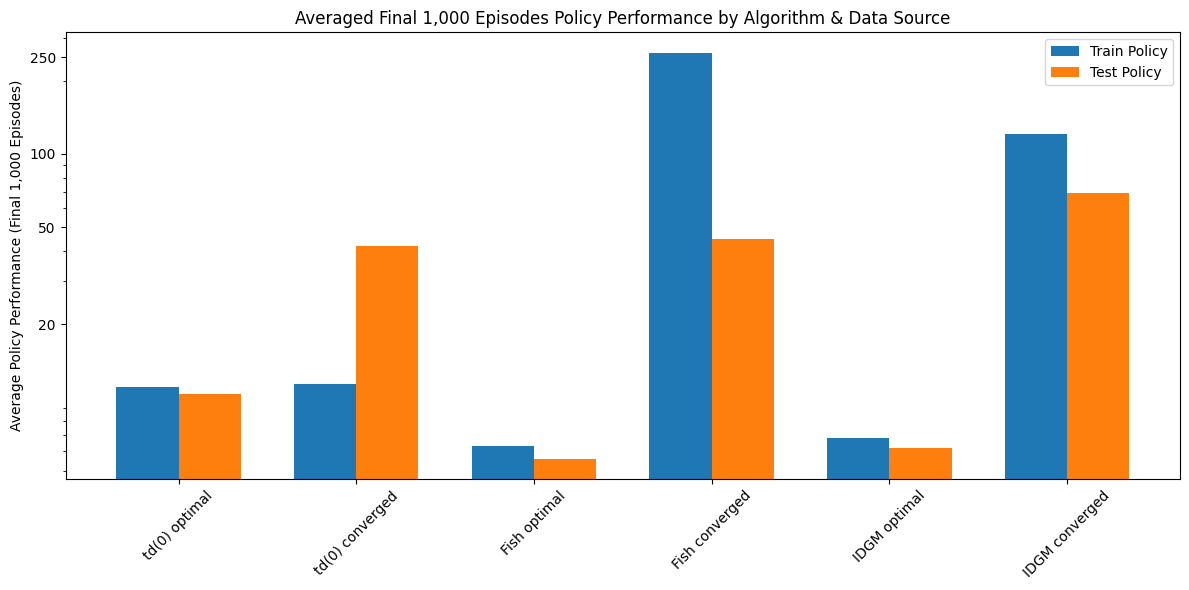

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Define the custom values for each bar (from left to right)
# Groups: "td(0) optimal", "td(0) converged", "Fish optimal", "Fish converged", "IDGM optimal", "IDGM converged"
# Each group has 2 bars: first is Train Policy, second is Test Policy.
train_vals = [11.0, 11.3, 6.3, 260.7, 6.8, 121.1]
test_vals  = [10.3, 41.8, 5.6, 44.6, 6.2, 69.3]

group_names = [
    "td(0) optimal", "td(0) converged",
    "Fish optimal", "Fish converged",
    "IDGM optimal", "IDGM converged"
]

x = np.arange(len(group_names))  # 6 groups
bar_width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

# Create the grouped bar chart with a logarithmic y-axis
bars_train = ax.bar(x - bar_width/2, train_vals, bar_width, label='Train Policy')
bars_test  = ax.bar(x + bar_width/2, test_vals, bar_width, label='Test Policy')

ax.set_ylabel('Average Policy Performance (Final 1,000 Episodes)')
ax.set_title('Averaged Final 1,000 Episodes Policy Performance by Algorithm & Data Source')
ax.set_xticks(x)
ax.set_xticklabels(group_names, rotation=45)
ax.legend()

# Set y-axis to logarithmic scale
ax.set_yscale("log")
yticks = [20, 50, 100, 250]
ax.set_yticks(yticks)
ax.set_yticklabels([f'{int(tick)}' for tick in yticks])

plt.tight_layout()
plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

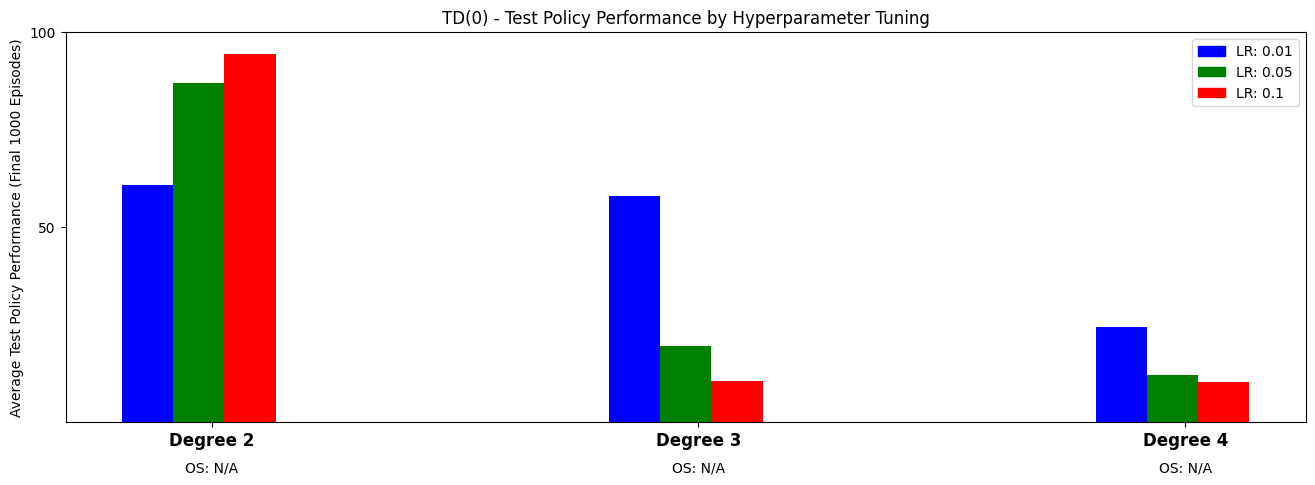

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

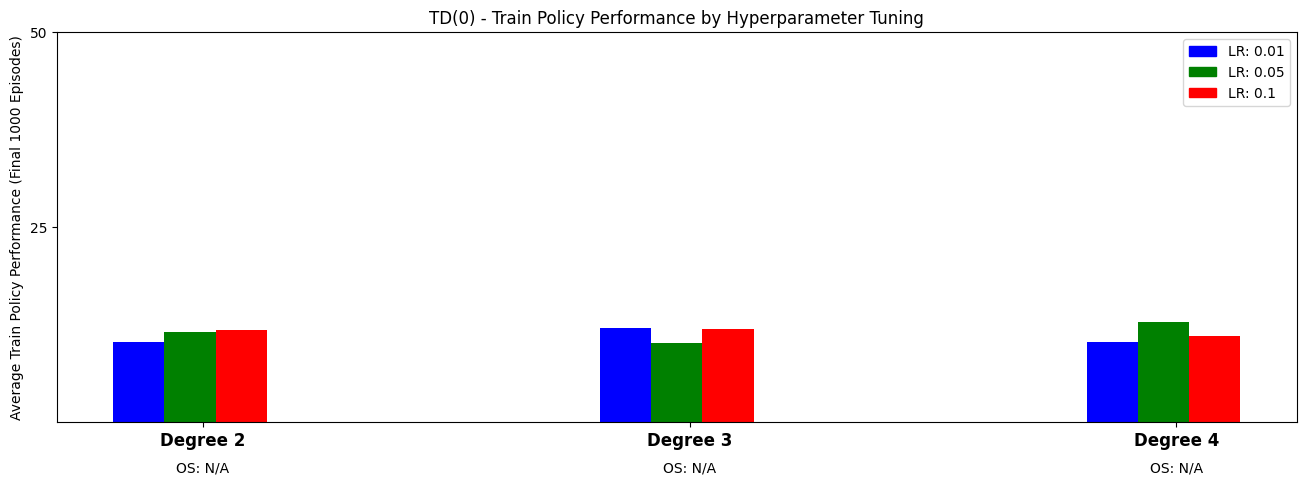

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

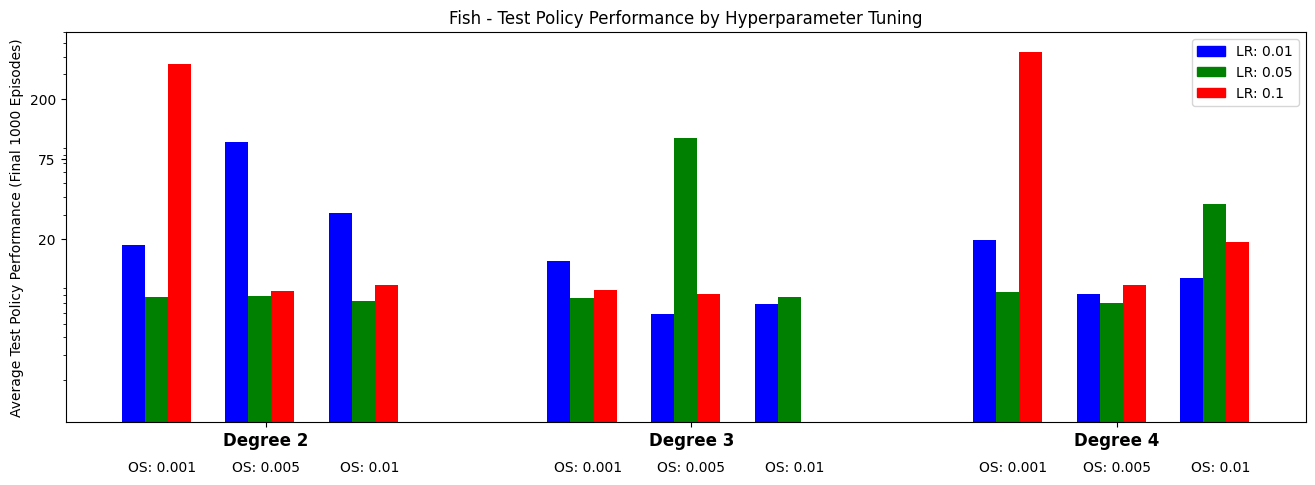

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

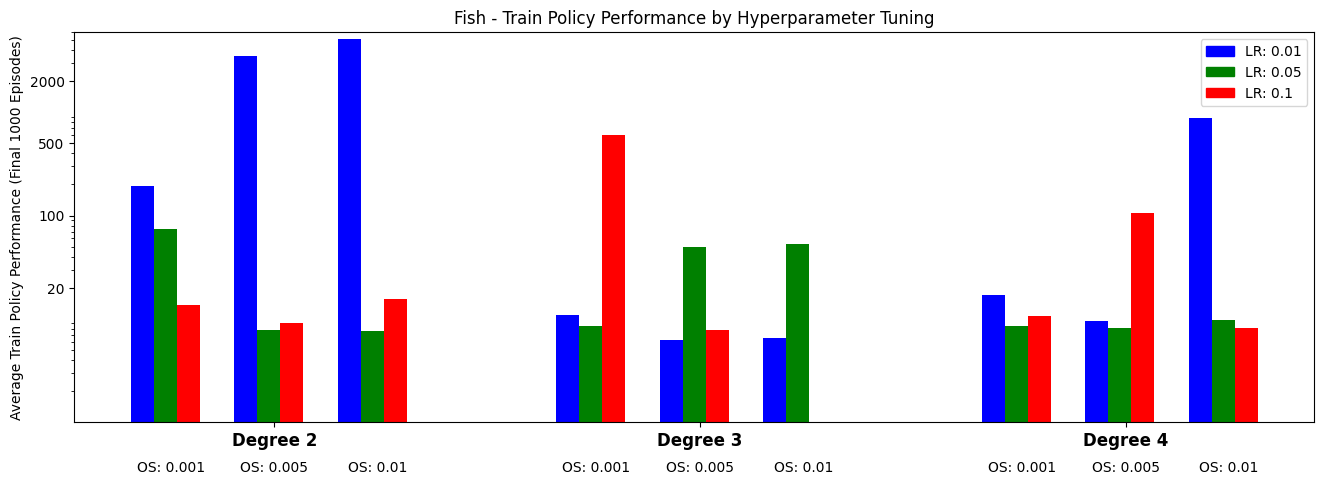

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

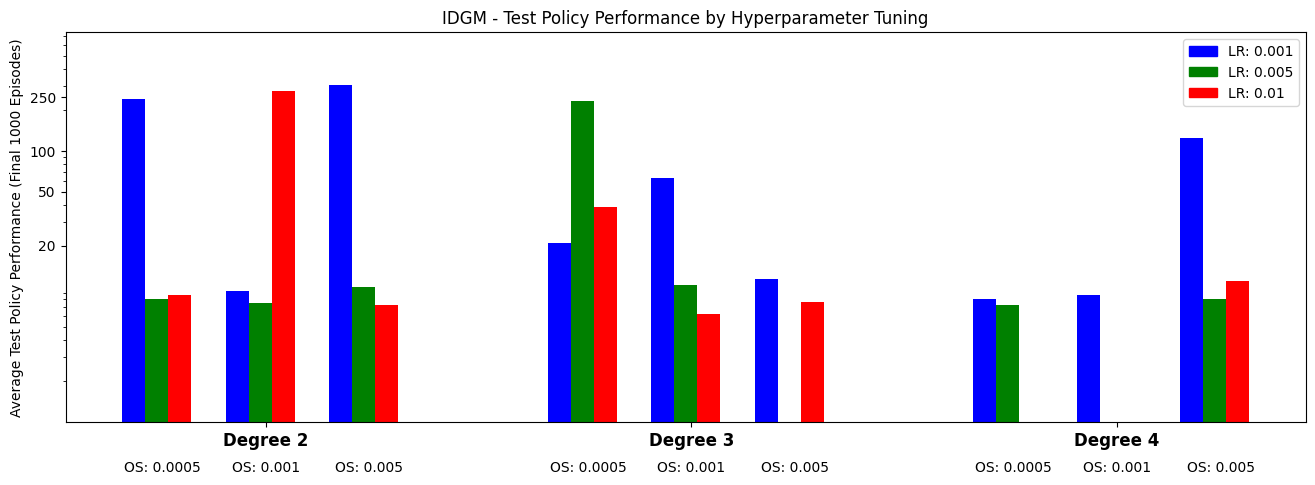

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

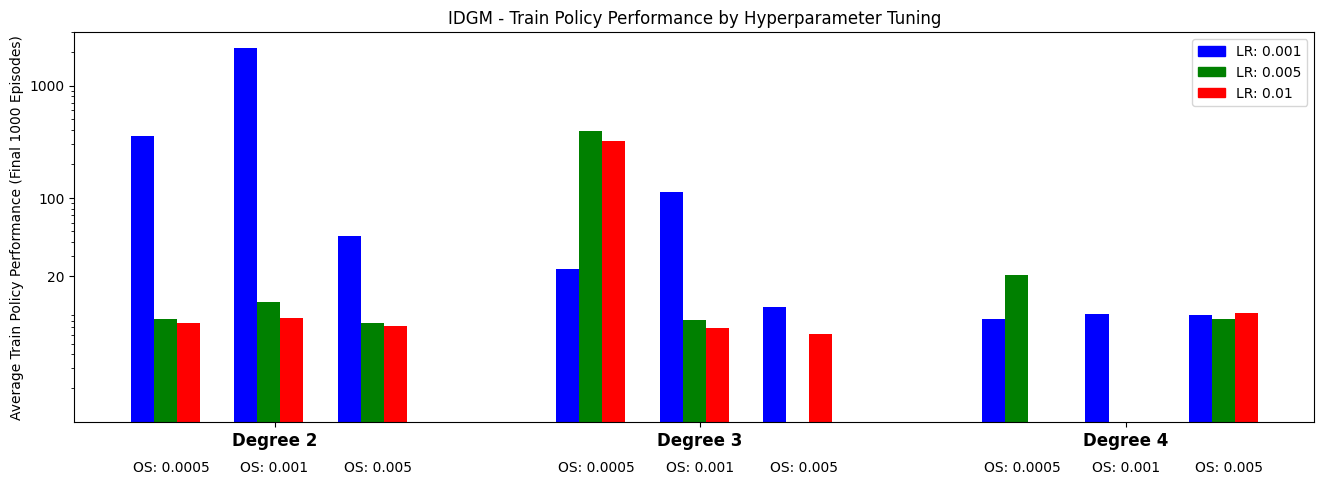

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from google.colab import files

# --- Common parameters ---
bar_width = 0.2
minor_gap = 0.3   # gap between outer groups
major_gap = 1.0   # gap between degree groups
lr_colors = ['blue', 'green', 'red']
yticks = [[50, 100],[25,50],[20, 75, 200],[20,100,500,2000],[20, 50, 100, 250],[20,100,1000]]

# --- New method for annotations ---
# Instead of computing y_min and y_max for each graph, we annotate in axis (x-axis) coordinates.
# Here, y=-0.1 in axis coordinates means 10% below the x-axis.
def annotate_outer_groups(ax, outer_centers, outer_labels):
    for center, lab in zip(outer_centers, outer_labels):
        # Use transform=ax.get_xaxis_transform() so that y is in relative coordinates.
        ax.text(center, -0.1, lab,
                transform=ax.get_xaxis_transform(),
                ha='center', va='top', fontsize=10)

# --- Helper function to compute x positions for a given grid ---
def compute_positions(n_degrees, n_outers, n_lrs):
    x_positions = []
    outer_centers = []
    degree_centers = []
    current_x = 0
    for deg in range(n_degrees):
        degree_start = current_x
        for outer in range(n_outers):
            outer_start = current_x
            for lr in range(n_lrs):
                x_positions.append(current_x)
                current_x += bar_width
            # Compute center for this outer group
            outer_center = (outer_start + current_x - bar_width/2) / 2
            outer_centers.append(outer_center)
            current_x += minor_gap
        degree_end = current_x - minor_gap
        degree_center = (degree_start + degree_end - bar_width/2) / 2
        degree_centers.append(degree_center)
        current_x += major_gap
    return x_positions, outer_centers, degree_centers

# --- TD(0) Data (one outer group, three learning rates, three degrees) ---
td0_test  = [60.655, 86.909, 94.382, 57.964, 19.491, 10.473, 24.309, 12.109, 10.345]
td0_train = [10.255, 11.545, 11.782, 12.018, 10.145, 11.982, 10.200, 12.800, 11.036]
n_degrees_td0 = 3
n_outers_td0 = 1
n_lrs_td0 = 3
td0_x, td0_outer_centers, td0_degree_centers = compute_positions(n_degrees_td0, n_outers_td0, n_lrs_td0)
td0_outer_labels = ["OS: N/A"] * len(td0_outer_centers)
td0_degree_labels = [f"Degree {d}" for d in [2, 3, 4]]
td0_lr_labels = ['0.01', '0.05', '0.1']

# --- Fish Data (three outer groups) ---
fish_test = [
    # Degree 2:
    18.136, 7.818, 355.394,    # outer=0.001
    99.500, 7.909, 8.545,       # outer=0.005
    30.909, 7.273, 9.394,       # outer=0.01
    # Degree 3:
    14.114, 7.606, 8.727,       # outer=0.001
    5.909, 106.295, 8.121,      # outer=0.005
    6.909, 7.773, np.nan,       # outer=0.01
    # Degree 4:
    19.705, 8.455, 430.636,     # outer=0.001
    8.152, 7.023, 9.500,        # outer=0.005
    10.636, 35.909, 19.068      # outer=0.01
]
fish_train = [
    # Degree 2:
    193.455, 74.909, 13.606,    # outer=0.001
    3496.455, 7.864, 9.000,     # outer=0.005
    5122.909, 7.697, 15.424,     # outer=0.01
    # Degree 3:
    10.773, 8.515, 604.273,      # outer=0.001
    6.273, 49.909, 7.848,        # outer=0.005
    6.455, 53.000, np.nan,       # outer=0.01
    # Degree 4:
    16.955, 8.485, 10.636,       # outer=0.001
    9.515, 8.159, 106.182,       # outer=0.005
    876.409, 9.636, 8.205        # outer=0.01
]
n_degrees_fish = 3
n_outers_fish = 3
n_lrs_fish = 3
fish_x, fish_outer_centers, fish_degree_centers = compute_positions(n_degrees_fish, n_outers_fish, n_lrs_fish)
# Outer labels: one for each outer group per degree (in order)
fish_outer_labels = []
for _ in range(n_degrees_fish):
    for os in [0.001, 0.005, 0.01]:
        fish_outer_labels.append(f"OS: {os}")
fish_degree_labels = [f"Degree {d}" for d in [2, 3, 4]]
fish_lr_labels = ['0.01', '0.05', '0.1']

# --- IDGM Data (three outer groups) ---
idgm_test = [
    # Degree 2:
    241.091, 8.000, 8.636,      # outer=0.0005
    9.273, 7.545, 275.515,       # outer=0.001
    305.364, 9.818, 7.250,       # outer=0.005
    # Degree 3:
    20.727, 232.818, 38.409,     # outer=0.0005
    62.545, 10.318, 6.227,       # outer=0.001
    11.364, np.nan, 7.636,       # outer=0.005
    # Degree 4:
    8.091, 7.227, np.nan,        # outer=0.0005
    8.667, np.nan, np.nan,        # outer=0.001
    123.591, 8.114, 10.864       # outer=0.005
]
idgm_train = [
    # Degree 2:
    351.409, 8.364, 7.591,       # outer=0.0005
    2155.727, 11.636, 8.515,      # outer=0.001
    45.182, 7.636, 7.159,         # outer=0.005
    # Degree 3:
    23.364, 389.409, 319.545,     # outer=0.0005
    112.212, 8.091, 6.818,        # outer=0.001
    10.636, np.nan, 6.091,         # outer=0.005
    # Degree 4:
    8.273, 20.409, np.nan,         # outer=0.0005
    9.273, np.nan, np.nan,         # outer=0.001
    8.909, 8.318, 9.364            # outer=0.005
]
n_degrees_idgm = 3
n_outers_idgm = 3
n_lrs_idgm = 3
idgm_x, idgm_outer_centers, idgm_degree_centers = compute_positions(n_degrees_idgm, n_outers_idgm, n_lrs_idgm)
idgm_outer_labels = []
for _ in range(n_degrees_idgm):
    for os in [0.0005, 0.001, 0.005]:
        idgm_outer_labels.append(f"OS: {os}")
idgm_degree_labels = [f"Degree {d}" for d in [2, 3, 4]]
idgm_lr_labels = ['0.001', '0.005', '0.01']

# --- Function to create a single bar chart ---
def create_chart(x_positions, bar_heights, degree_centers, degree_labels,
                 outer_centers, outer_labels, title, ylabel, lr_labels, num):
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.bar(x_positions, bar_heights, width=bar_width, color=[lr_colors[i % len(lr_labels)] for i in range(len(x_positions))])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(degree_centers)
    ax.set_xticklabels(degree_labels, fontsize=12, fontweight='bold')

    # Annotate outer groups using x-axis transform so annotations remain fixed relative to the axis.
    annotate_outer_groups(ax, outer_centers, outer_labels)

    if(x_positions!=td0_x):
        ax.set_yscale("log")
    ax.set_yticks(yticks[num])
    ax.set_yticklabels([str(t) for t in yticks[num]])
    if(x_positions!=td0_x):
        ax.set_ylim([1,3*max(yticks[num])])

    legend_handles = [Patch(color=lr_colors[i], label=f"LR: {lr_labels[i]}") for i in range(len(lr_labels))]
    ax.legend(handles=legend_handles)

    # Adjust the subplot to leave space at the bottom for annotations.
    fig.subplots_adjust(bottom=0.25, top=0.9)
    plt.savefig(f"ResearchBarChart{num}.png", dpi=300)
    files.download(f"ResearchBarChart{num}.png")
    plt.show()

# --- Create the 6 graphs ---

# TD(0) - Test
create_chart(
    x_positions=td0_x,
    bar_heights=td0_test,
    degree_centers=td0_degree_centers,
    degree_labels=td0_degree_labels,
    outer_centers=td0_outer_centers,
    outer_labels=td0_outer_labels,
    title="TD(0) - Test Policy Performance by Hyperparameter Tuning",
    ylabel="Average Test Policy Performance (Final 1000 Episodes)",
    lr_labels=td0_lr_labels,
    num=0
)

# TD(0) - Train
create_chart(
    x_positions=td0_x,
    bar_heights=td0_train,
    degree_centers=td0_degree_centers,
    degree_labels=td0_degree_labels,
    outer_centers=td0_outer_centers,
    outer_labels=td0_outer_labels,
    title="TD(0) - Train Policy Performance by Hyperparameter Tuning",
    ylabel="Average Train Policy Performance (Final 1000 Episodes)",
    lr_labels=td0_lr_labels,
    num=1
)

# Fish - Test
create_chart(
    x_positions=fish_x,
    bar_heights=fish_test,
    degree_centers=fish_degree_centers,
    degree_labels=fish_degree_labels,
    outer_centers=fish_outer_centers,
    outer_labels=fish_outer_labels,
    title="Fish - Test Policy Performance by Hyperparameter Tuning",
    ylabel="Average Test Policy Performance (Final 1000 Episodes)",
    lr_labels=fish_lr_labels,
    num=2
)

# Fish - Train
create_chart(
    x_positions=fish_x,
    bar_heights=fish_train,
    degree_centers=fish_degree_centers,
    degree_labels=fish_degree_labels,
    outer_centers=fish_outer_centers,
    outer_labels=fish_outer_labels,
    title="Fish - Train Policy Performance by Hyperparameter Tuning",
    ylabel="Average Train Policy Performance (Final 1000 Episodes)",
    lr_labels=fish_lr_labels,
    num=3
)

# IDGM - Test
create_chart(
    x_positions=idgm_x,
    bar_heights=idgm_test,
    degree_centers=idgm_degree_centers,
    degree_labels=idgm_degree_labels,
    outer_centers=idgm_outer_centers,
    outer_labels=idgm_outer_labels,
    title="IDGM - Test Policy Performance by Hyperparameter Tuning",
    ylabel="Average Test Policy Performance (Final 1000 Episodes)",
    lr_labels=idgm_lr_labels,
    num=4
)

# IDGM - Train
create_chart(
    x_positions=idgm_x,
    bar_heights=idgm_train,
    degree_centers=idgm_degree_centers,
    degree_labels=idgm_degree_labels,
    outer_centers=idgm_outer_centers,
    outer_labels=idgm_outer_labels,
    title="IDGM - Train Policy Performance by Hyperparameter Tuning",
    ylabel="Average Train Policy Performance (Final 1000 Episodes)",
    lr_labels=idgm_lr_labels,
    num=5
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

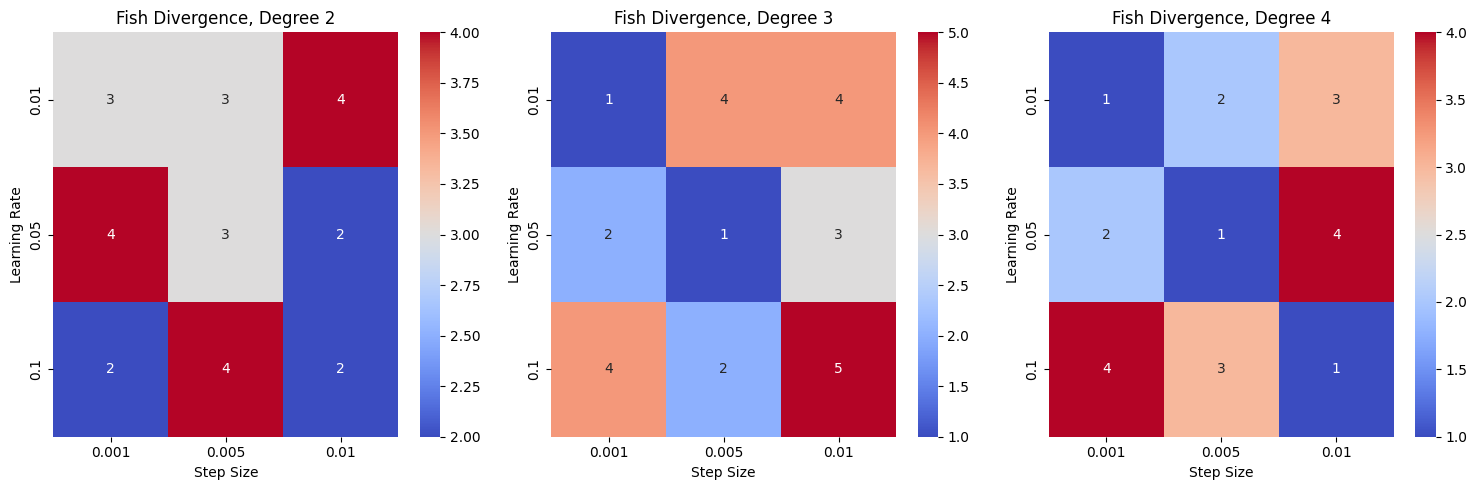

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

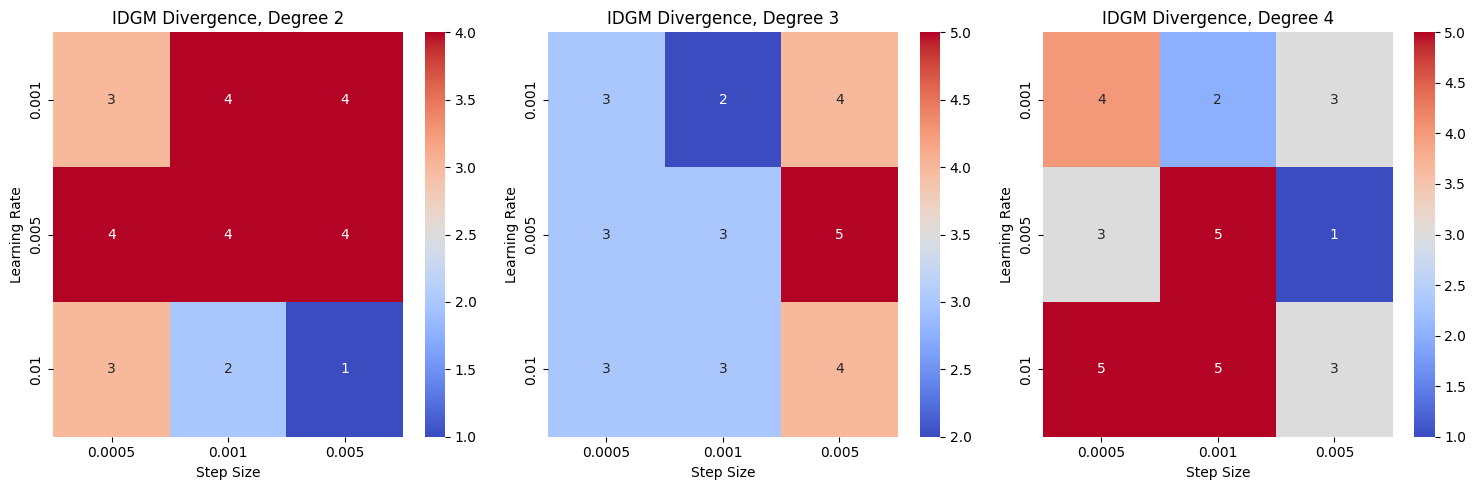

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Define parameter grids
fish_lr = [0.01, 0.05, 0.1]
fish_step = [0.001, 0.005, 0.01]
fish_degree = [2, 3, 4]

idgm_lr = [0.001, 0.005, 0.01]
idgm_step = [0.0005, 0.001, 0.005]
idgm_degree = [2, 3, 4]

# Create dictionaries to hold divergence counts
fish_divergence = np.zeros((3, 3, 3))  # Learning Rate x Step Size x Degree
idgm_divergence = np.zeros((3, 3, 3))

# Example: "Trial 0 in Fish 111 diverged. Skipping." → Fish, (1,1,1)
data = """Trial 0 in Fish 111 diverged. Skipping.
Trial 2 in Fish 111 diverged. Skipping.
Trial 4 in Fish 111 diverged. Skipping.
Trial 2 in Fish 112 diverged. Skipping.
Trial 1 in Fish 113 diverged. Skipping.
Trial 1 in Fish 121 diverged. Skipping.
Trial 2 in Fish 121 diverged. Skipping.
Trial 4 in Fish 121 diverged. Skipping.
Trial 1 in Fish 122 diverged. Skipping.
Trial 2 in Fish 122 diverged. Skipping.
Trial 3 in Fish 122 diverged. Skipping.
Trial 4 in Fish 122 diverged. Skipping.
Trial 1 in Fish 123 diverged. Skipping.
Trial 2 in Fish 123 diverged. Skipping.
Trial 1 in Fish 131 diverged. Skipping.
Trial 2 in Fish 131 diverged. Skipping.
Trial 3 in Fish 131 diverged. Skipping.
Trial 4 in Fish 131 diverged. Skipping.
Trial 0 in Fish 132 diverged. Skipping.
Trial 1 in Fish 132 diverged. Skipping.
Trial 2 in Fish 132 diverged. Skipping.
Trial 4 in Fish 132 diverged. Skipping.
Trial 0 in Fish 133 diverged. Skipping.
Trial 2 in Fish 133 diverged. Skipping.
Trial 3 in Fish 133 diverged. Skipping.
Trial 1 in Fish 211 diverged. Skipping.
Trial 2 in Fish 211 diverged. Skipping.
Trial 3 in Fish 211 diverged. Skipping.
Trial 4 in Fish 211 diverged. Skipping.
Trial 2 in Fish 212 diverged. Skipping.
Trial 4 in Fish 212 diverged. Skipping.
Trial 0 in Fish 213 diverged. Skipping.
Trial 2 in Fish 213 diverged. Skipping.
Trial 0 in Fish 221 diverged. Skipping.
Trial 3 in Fish 221 diverged. Skipping.
Trial 4 in Fish 221 diverged. Skipping.
Trial 3 in Fish 222 diverged. Skipping.
Trial 0 in Fish 223 diverged. Skipping.
Trial 1 in Fish 231 diverged. Skipping.
Trial 4 in Fish 231 diverged. Skipping.
Trial 0 in Fish 232 diverged. Skipping.
Trial 2 in Fish 232 diverged. Skipping.
Trial 3 in Fish 232 diverged. Skipping.
Trial 0 in Fish 233 diverged. Skipping.
Trial 2 in Fish 233 diverged. Skipping.
Trial 3 in Fish 233 diverged. Skipping.
Trial 4 in Fish 233 diverged. Skipping.
Trial 1 in Fish 311 diverged. Skipping.
Trial 4 in Fish 311 diverged. Skipping.
Trial 0 in Fish 312 diverged. Skipping.
Trial 1 in Fish 312 diverged. Skipping.
Trial 3 in Fish 312 diverged. Skipping.
Trial 4 in Fish 312 diverged. Skipping.
Trial 0 in Fish 313 diverged. Skipping.
Trial 2 in Fish 313 diverged. Skipping.
Trial 3 in Fish 313 diverged. Skipping.
Trial 4 in Fish 313 diverged. Skipping.
Trial 0 in Fish 321 diverged. Skipping.
Trial 1 in Fish 321 diverged. Skipping.
Trial 3 in Fish 321 diverged. Skipping.
Trial 4 in Fish 321 diverged. Skipping.
Trial 0 in Fish 322 diverged. Skipping.
Trial 4 in Fish 322 diverged. Skipping.
Trial 1 in Fish 323 diverged. Skipping.
Trial 2 in Fish 323 diverged. Skipping.
Trial 4 in Fish 323 diverged. Skipping.
Trial 0 in Fish 331 diverged. Skipping.
Trial 1 in Fish 331 diverged. Skipping.
Trial 0 in Fish 332 diverged. Skipping.
Trial 1 in Fish 332 diverged. Skipping.
Trial 2 in Fish 332 diverged. Skipping.
Trial 3 in Fish 332 diverged. Skipping.
Trial 4 in Fish 332 diverged. Skipping.
Trial 3 in Fish 333 diverged. Skipping.
Trial 2 in IDGM 111 diverged. Skipping.
Trial 3 in IDGM 111 diverged. Skipping.
Trial 4 in IDGM 111 diverged. Skipping.
Trial 2 in IDGM 112 diverged. Skipping.
Trial 3 in IDGM 112 diverged. Skipping.
Trial 4 in IDGM 112 diverged. Skipping.
Trial 0 in IDGM 113 diverged. Skipping.
Trial 2 in IDGM 113 diverged. Skipping.
Trial 3 in IDGM 113 diverged. Skipping.
Trial 4 in IDGM 113 diverged. Skipping.
Trial 0 in IDGM 121 diverged. Skipping.
Trial 1 in IDGM 121 diverged. Skipping.
Trial 2 in IDGM 121 diverged. Skipping.
Trial 4 in IDGM 121 diverged. Skipping.
Trial 1 in IDGM 122 diverged. Skipping.
Trial 3 in IDGM 122 diverged. Skipping.
Trial 1 in IDGM 123 diverged. Skipping.
Trial 3 in IDGM 123 diverged. Skipping.
Trial 0 in IDGM 131 diverged. Skipping.
Trial 2 in IDGM 131 diverged. Skipping.
Trial 3 in IDGM 131 diverged. Skipping.
Trial 4 in IDGM 131 diverged. Skipping.
Trial 0 in IDGM 132 diverged. Skipping.
Trial 1 in IDGM 132 diverged. Skipping.
Trial 2 in IDGM 132 diverged. Skipping.
Trial 3 in IDGM 132 diverged. Skipping.
Trial 1 in IDGM 133 diverged. Skipping.
Trial 2 in IDGM 133 diverged. Skipping.
Trial 3 in IDGM 133 diverged. Skipping.
Trial 0 in IDGM 211 diverged. Skipping.
Trial 1 in IDGM 211 diverged. Skipping.
Trial 3 in IDGM 211 diverged. Skipping.
Trial 4 in IDGM 211 diverged. Skipping.
Trial 0 in IDGM 212 diverged. Skipping.
Trial 3 in IDGM 212 diverged. Skipping.
Trial 4 in IDGM 212 diverged. Skipping.
Trial 1 in IDGM 213 diverged. Skipping.
Trial 2 in IDGM 213 diverged. Skipping.
Trial 3 in IDGM 213 diverged. Skipping.
Trial 0 in IDGM 221 diverged. Skipping.
Trial 1 in IDGM 221 diverged. Skipping.
Trial 2 in IDGM 221 diverged. Skipping.
Trial 3 in IDGM 221 diverged. Skipping.
Trial 1 in IDGM 222 diverged. Skipping.
Trial 3 in IDGM 222 diverged. Skipping.
Trial 4 in IDGM 222 diverged. Skipping.
Trial 0 in IDGM 223 diverged. Skipping.
Trial 1 in IDGM 223 diverged. Skipping.
Trial 2 in IDGM 223 diverged. Skipping.
Trial 3 in IDGM 223 diverged. Skipping.
Trial 4 in IDGM 223 diverged. Skipping.
Trial 0 in IDGM 231 diverged. Skipping.
Trial 1 in IDGM 231 diverged. Skipping.
Trial 2 in IDGM 231 diverged. Skipping.
Trial 3 in IDGM 231 diverged. Skipping.
Trial 0 in IDGM 232 diverged. Skipping.
Trial 1 in IDGM 232 diverged. Skipping.
Trial 2 in IDGM 232 diverged. Skipping.
Trial 3 in IDGM 232 diverged. Skipping.
Trial 4 in IDGM 232 diverged. Skipping.
Trial 4 in IDGM 233 diverged. Skipping.
Trial 1 in IDGM 311 diverged. Skipping.
Trial 3 in IDGM 311 diverged. Skipping.
Trial 4 in IDGM 311 diverged. Skipping.
Trial 1 in IDGM 312 diverged. Skipping.
Trial 2 in IDGM 312 diverged. Skipping.
Trial 3 in IDGM 312 diverged. Skipping.
Trial 0 in IDGM 313 diverged. Skipping.
Trial 1 in IDGM 313 diverged. Skipping.
Trial 2 in IDGM 313 diverged. Skipping.
Trial 3 in IDGM 313 diverged. Skipping.
Trial 4 in IDGM 313 diverged. Skipping.
Trial 1 in IDGM 321 diverged. Skipping.
Trial 3 in IDGM 321 diverged. Skipping.
Trial 2 in IDGM 322 diverged. Skipping.
Trial 3 in IDGM 322 diverged. Skipping.
Trial 4 in IDGM 322 diverged. Skipping.
Trial 0 in IDGM 323 diverged. Skipping.
Trial 1 in IDGM 323 diverged. Skipping.
Trial 2 in IDGM 323 diverged. Skipping.
Trial 3 in IDGM 323 diverged. Skipping.
Trial 4 in IDGM 323 diverged. Skipping.
Trial 0 in IDGM 331 diverged. Skipping.
Trial 1 in IDGM 332 diverged. Skipping.
Trial 2 in IDGM 332 diverged. Skipping.
Trial 3 in IDGM 332 diverged. Skipping.
Trial 4 in IDGM 332 diverged. Skipping.
Trial 1 in IDGM 333 diverged. Skipping.
Trial 3 in IDGM 333 diverged. Skipping.
Trial 4 in IDGM 333 diverged. Skipping."""  # Replace this with the full text

for line in data.split("\n"):
    parts = line.split()
    if len(parts) < 5:
        continue

    trial, algo, indices = int(parts[1]), parts[3], parts[4]
    i, j, k = int(indices[0])-1, int(indices[1])-1, int(indices[2])-1

    if "Fish" in algo:
        fish_divergence[i, j, k] += 1
    elif "IDGM" in algo:
        idgm_divergence[i, j, k] += 1

# Function to plot heatmaps
def plot_heatmaps(divergence_matrix, title, lrs, steps, degrees):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for k, ax in enumerate(axes):
        sns.heatmap(divergence_matrix[:, :, k], annot=True, fmt=".0f", cmap="coolwarm",
                    xticklabels=steps, yticklabels=lrs, ax=ax)
        ax.set_title(f"{title}, Degree {degrees[k]}")
        ax.set_xlabel("Step Size")
        ax.set_ylabel("Learning Rate")

    plt.tight_layout()
    plt.savefig(f"{title}.png", dpi=300)
    files.download(f"{title}.png")
    plt.show()

# Plot heatmaps
plot_heatmaps(fish_divergence, "Fish Divergence", fish_lr, fish_step, fish_degree)
plot_heatmaps(idgm_divergence, "IDGM Divergence", idgm_lr, idgm_step, idgm_degree)